## **Data Cleaning & Preprocessing → using House dataset**

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### **Load Dataset**

In [4]:
df = pd.read_csv("house Prediction Data Set.csv", sep=r'\s+')

columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS",
           "RAD","TAX","PTRATIO","B","LSTAT","MEDV"]

df.columns = columns

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


### **Checking missing values**

In [5]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


### **Dataset information**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     505 non-null    float64
 1   ZN       505 non-null    float64
 2   INDUS    505 non-null    float64
 3   CHAS     505 non-null    int64  
 4   NOX      505 non-null    float64
 5   RM       505 non-null    float64
 6   AGE      505 non-null    float64
 7   DIS      505 non-null    float64
 8   RAD      505 non-null    int64  
 9   TAX      505 non-null    float64
 10  PTRATIO  505 non-null    float64
 11  B        505 non-null    float64
 12  LSTAT    505 non-null    float64
 13  MEDV     505 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.4 KB


### **Outlier Visualization**

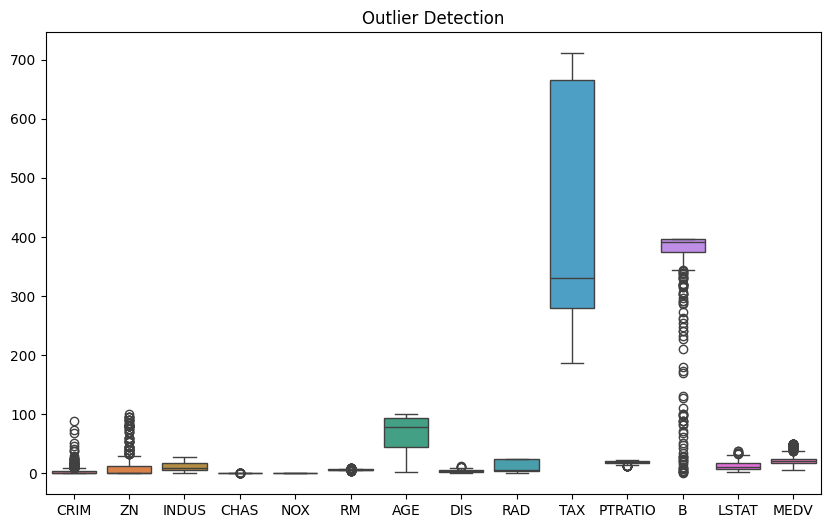

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

### **Remove Outliers**

In [8]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (505, 14)
Cleaned Shape: (268, 14)


### **Standardize data**

In [9]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

df_scaled = pd.DataFrame(scaled_data, columns=df_clean.columns)

df_scaled.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,-0.508717,-0.448939,-0.576642,0.0,-0.673307,0.603120,0.476247,0.544282,-0.746350,-0.859834,-0.587849,0.701093,-0.534720,0.055527
1,-0.508728,-0.448939,-0.576642,0.0,-0.673307,2.387557,-0.189274,0.544282,-0.746350,-0.859834,-0.587849,0.345185,-1.475602,2.793522
2,-0.506132,-0.448939,-1.340857,0.0,-0.786647,1.950790,-0.761323,1.162528,-0.597745,-1.001045,-0.069424,0.502589,-1.676299,2.521813
3,-0.487390,-0.448939,-1.340857,0.0,-0.786647,2.298802,-0.447257,1.162528,-0.597745,-1.001045,-0.069424,0.701093,-1.236238,3.107033
4,-0.507420,-0.448939,-1.340857,0.0,-0.786647,0.624141,-0.279007,1.162528,-0.597745,-1.001045,-0.069424,0.457991,-1.258333,1.539479


### **Save Clean Dataset**

In [10]:
df_scaled.to_csv("cleaned_house_data.csv", index=False)